# Apple Stock Price Prediction Using an LSTM-Based Recurrent Neural Network

## 2. Import Libraries

In [2]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

YFINANCE_CACHE_DIR = Path(".yfinance_cache")
YFINANCE_CACHE_DIR.mkdir(exist_ok=True)
yf.set_tz_cache_location(str(YFINANCE_CACHE_DIR))

plt.style.use("seaborn-v0_8-whitegrid")

## 3. Data Collection

In [4]:
ticker = "AAPL"
start_date = "2015-01-01"
end_date = "2026-01-01"
data_file = Path("AAPL_stock_data.csv")

try:
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        progress=False,
        auto_adjust=False,
    )
    if data.empty:
        raise ValueError("Yahoo Finance returned an empty dataset.")
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    data.to_csv(data_file)
    print("Downloaded AAPL stock data from Yahoo Finance.")
except Exception:
    print("Using cached AAPL_stock_data.csv because Yahoo Finance download was unavailable.")
    data = pd.read_csv(data_file, index_col=0, parse_dates=True)

data.index = pd.to_datetime(data.index)
data = data.sort_index()

print("First 5 rows:")
display(data.head())

print("Last 5 rows:")
display(data.tail())

print("Dataset shape:")
display(pd.DataFrame({"Rows": [data.shape[0]], "Columns": [data.shape[1]]}))

print("Column names:")
display(pd.DataFrame({"Column Names": data.columns}))

print("Descriptive statistics:")
display(data.describe())

Downloaded AAPL stock data from Yahoo Finance.
First 5 rows:
Last 5 rows:
Dataset shape:
Column names:
Descriptive statistics:


Price       Adj Close      Close       High        Low       Open     Volume
Date                                                                        
2015-01-02  24.192602  27.332500  27.860001  26.837500  27.847500  212818400
2015-01-05  23.511063  26.562500  27.162500  26.352501  27.072500  257142000
2015-01-06  23.513275  26.565001  26.857500  26.157499  26.635000  263188400
2015-01-07  23.842987  26.937500  27.049999  26.674999  26.799999  160423600
2015-01-08  24.759079  27.972500  28.037500  27.174999  27.307501  237458000

Price        Adj Close       Close  ...        Open    Volume
Date                                ...                      
2025-12-24  273.302216  273.809998  ...  272.339996  17910600
2025-12-26  272.892975  273.399994  ...  274.160004  21521800
2025-12-29  273.252350  273.760010  ...  272.690002  23715200
2025-12-30  272.573578  273.079987  ...  272.809998  22139600
2025-12-31  271.355835  271.859985  ...  273.059998  27293600

[5 rows x 6 columns]

   Rows  Columns
0  2766        6

  Column Names
0    Adj Close
1        Close
2         High
3          Low
4         Open
5       Volume

Price    Adj Close        Close  ...         Open        Volume
count  2766.000000  2766.000000  ...  2766.000000  2.766000e+03
mean    106.127485   108.644931  ...   108.546994  1.113994e+08
std      74.183369    73.856228  ...    73.777601  6.804243e+07
min      20.565866    22.584999  ...    22.500000  1.791060e+07
25%      36.583483    39.080626  ...    39.160000  6.488962e+07
50%      88.307220    91.204998  ...    91.176250  9.454380e+07
75%     168.334431   170.830006  ...   170.955002  1.372937e+08
max     285.659271   286.190002  ...   286.200012  6.488252e+08

[8 rows x 6 columns]

## 4. Data Cleaning

In [6]:
print("Missing values before cleaning:")
display(data.isnull().sum().to_frame("Missing Values"))

duplicate_rows = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    data = data.drop_duplicates()
    print("Duplicate rows dropped.")
else:
    print("No duplicate rows found.")

data = data.dropna()

print("Missing values after cleaning:")
display(data.isnull().sum().to_frame("Missing Values"))

print("Cleaned dataset shape:")
display(pd.DataFrame({"Rows": [data.shape[0]], "Columns": [data.shape[1]]}))

Missing values before cleaning:
Number of duplicate rows: 0
No duplicate rows found.
Missing values after cleaning:
Cleaned dataset shape:


           Missing Values
Price                    
Adj Close               0
Close                   0
High                    0
Low                     0
Open                    0
Volume                  0

           Missing Values
Price                    
Adj Close               0
Close                   0
High                    0
Low                     0
Open                    0
Volume                  0

   Rows  Columns
0  2766        6

## 5. Data Visualization

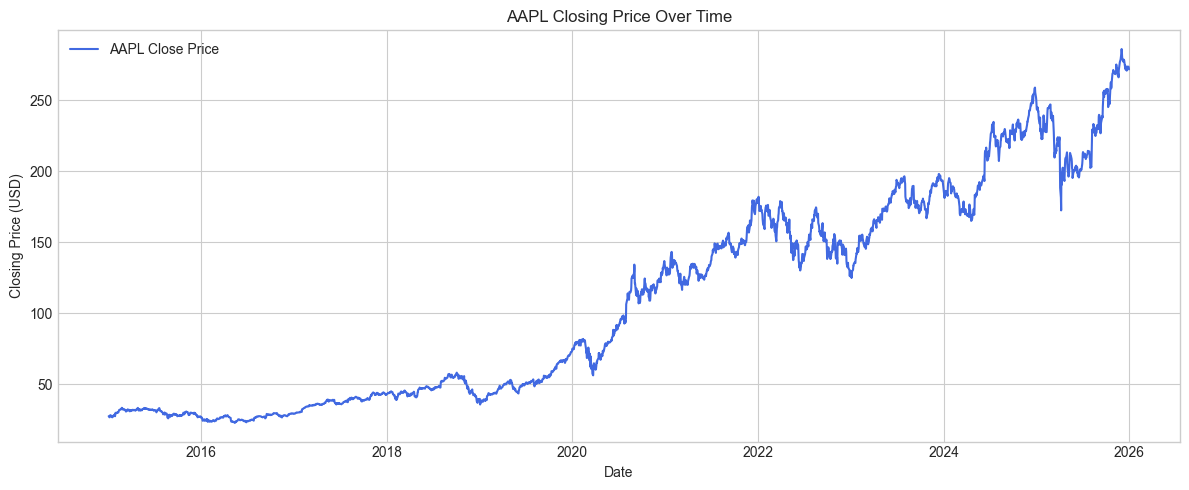

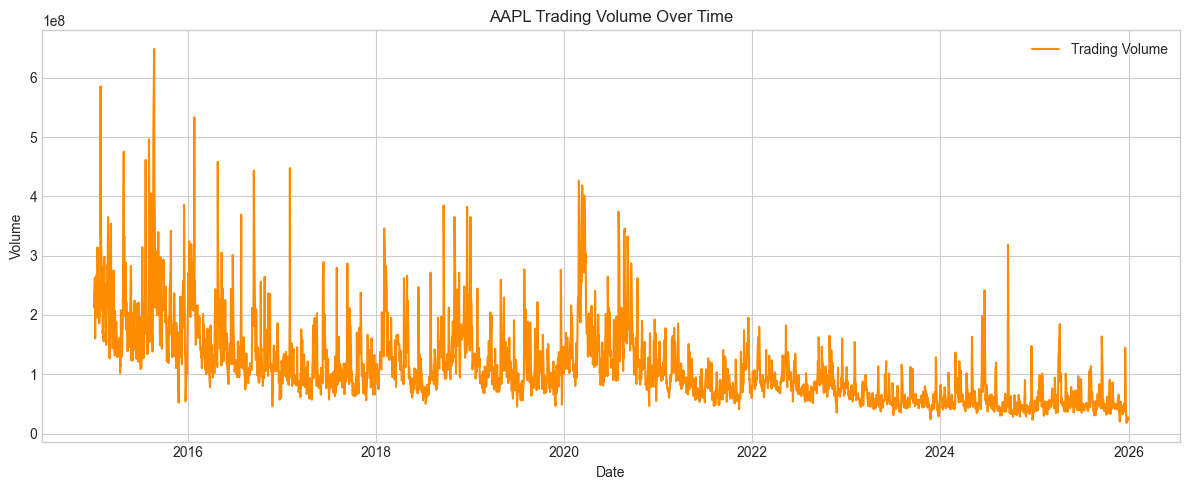

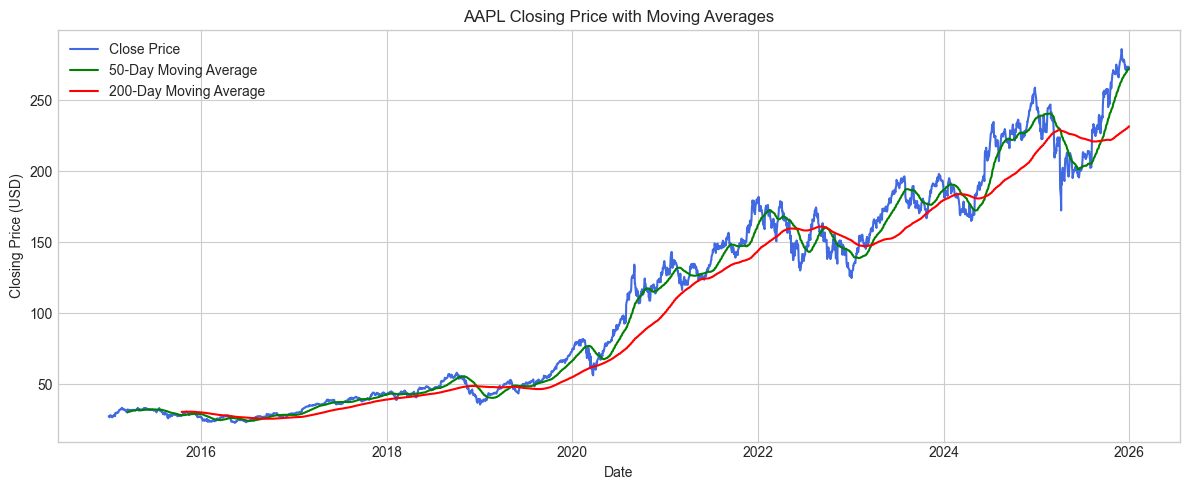

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Close"], color="royalblue", label="AAPL Close Price")
plt.title("AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_01_close_price_trend.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Volume"], color="darkorange", label="Trading Volume")
plt.title("AAPL Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_02_volume_trend.png", dpi=150)
plt.show()

moving_average_data = data[["Close"]].copy()
moving_average_data["MA_50"] = moving_average_data["Close"].rolling(window=50).mean()
moving_average_data["MA_200"] = moving_average_data["Close"].rolling(window=200).mean()

plt.figure(figsize=(12, 5))
plt.plot(moving_average_data.index, moving_average_data["Close"], label="Close Price", color="royalblue")
plt.plot(moving_average_data.index, moving_average_data["MA_50"], label="50-Day Moving Average", color="green")
plt.plot(moving_average_data.index, moving_average_data["MA_200"], label="200-Day Moving Average", color="red")
plt.title("AAPL Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_03_moving_averages.png", dpi=150)
plt.show()

## 6. Preprocessing and Sequence Preparation

In [10]:
lookback = 60
close_prices = data[["Close"]].copy()

train_size = int(len(close_prices) * 0.8)
train_data = close_prices.iloc[:train_size]
test_data = close_prices.iloc[train_size - lookback:]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)


def create_sequences(values, lookback_window):
    X, y = [], []
    for i in range(lookback_window, len(values)):
        X.append(values[i - lookback_window:i, 0])
        y.append(values[i, 0])
    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled, lookback)
X_test, y_test = create_sequences(test_scaled, lookback)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

test_dates = close_prices.index[train_size:]

print("Training period:", train_data.index.min().date(), "to", train_data.index.max().date())
print("Testing period:", close_prices.index[train_size].date(), "to", close_prices.index.max().date())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Training period: 2015-01-02 to 2023-10-16
Testing period: 2023-10-17 to 2025-12-31
X_train shape: (2152, 60, 1)
X_test shape: (554, 60, 1)
y_train shape: (2152,)
y_test shape: (554,)


## 7. LSTM Model Development

In [12]:
lstm_model = Sequential([
    Input(shape=(lookback, 1)),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1),
])

lstm_model.compile(optimizer="adam", loss="mean_squared_error")
lstm_model.summary()

Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴─────────────────────

## 8. LSTM Training

Epochs trained: 6
Final training loss: 0.002336
Final validation loss: 0.006624


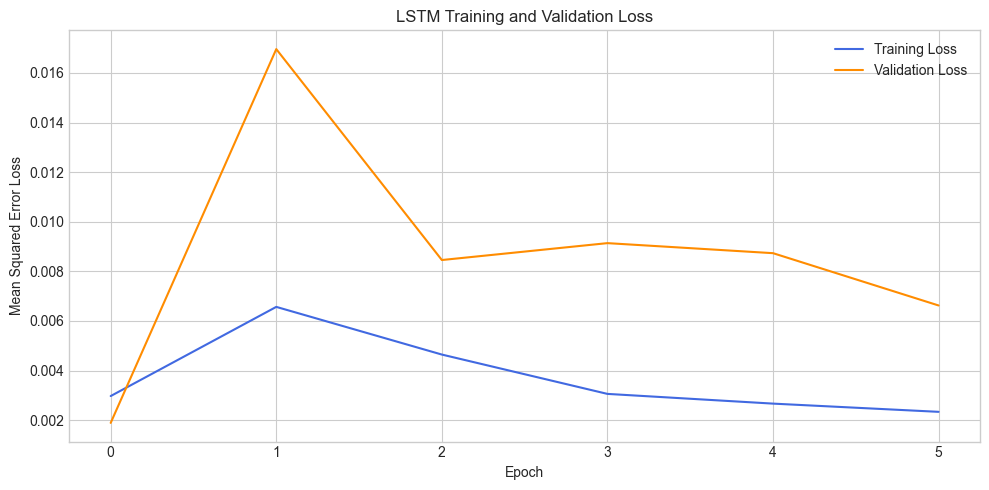

In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=0,
)

print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Final training loss: {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss", color="royalblue")
plt.plot(history.history["val_loss"], label="Validation Loss", color="darkorange")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_04_lstm_training_loss.png", dpi=150)
plt.show()

## 9. LSTM Prediction and Evaluation

In [16]:
def calculate_metrics(actual, predicted, epsilon=1e-8):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / (actual + epsilon))) * 100
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "MAPE (%)": mape,
    }


lstm_pred_scaled = lstm_model.predict(X_test, verbose=0)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).ravel()
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

lstm_metrics = calculate_metrics(actual_prices, lstm_pred)
lstm_metrics_df = pd.DataFrame([lstm_metrics], index=["LSTM"])

display(lstm_metrics_df)

            MAE       RMSE  R2 Score  MAPE (%)
LSTM  18.319093  22.417698  0.411673  7.871607

## 10. Random Forest Comparison

In [18]:
X_train_rf = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test_rf = X_test.reshape(X_test.shape[0], X_test.shape[1])

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_SEED,
)
rf_model.fit(X_train_rf, y_train)

rf_pred_scaled = rf_model.predict(X_test_rf).reshape(-1, 1)
rf_pred = scaler.inverse_transform(rf_pred_scaled).ravel()

rf_metrics = calculate_metrics(actual_prices, rf_pred)

comparison_df = pd.DataFrame(
    [lstm_metrics, rf_metrics],
    index=["LSTM", "Random Forest"],
)[["MAE", "RMSE", "R2 Score", "MAPE (%)"]]

display(comparison_df)

                     MAE       RMSE  R2 Score   MAPE (%)
LSTM           18.319093  22.417698  0.411673   7.871607
Random Forest  27.285858  36.604641 -0.568590  11.393788

## 11. Results Visualization

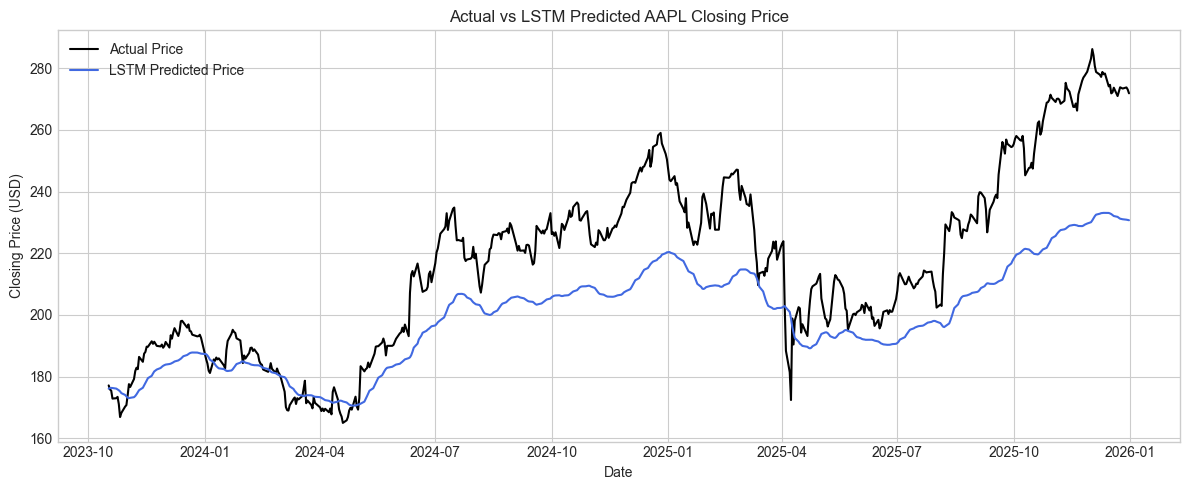

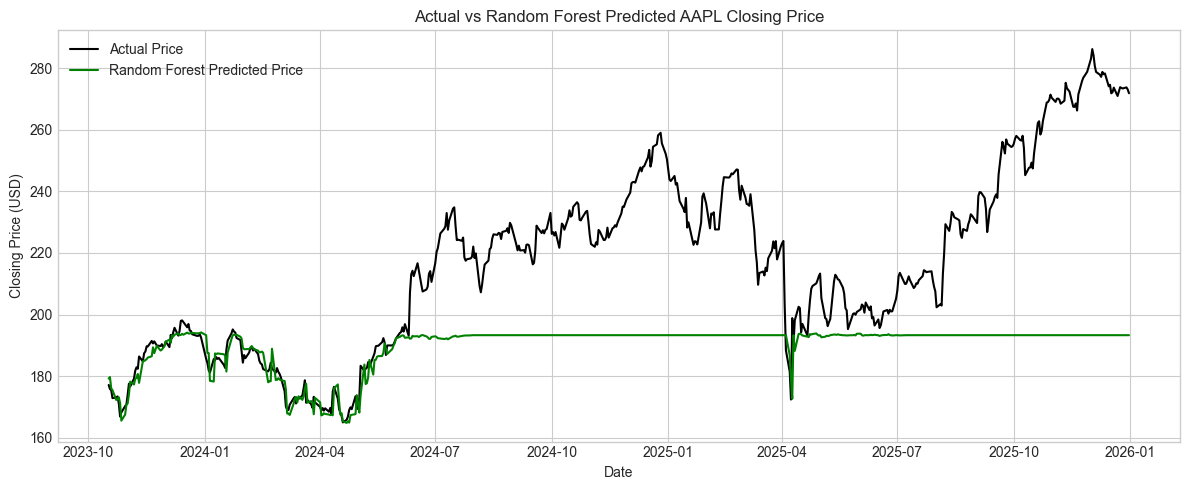

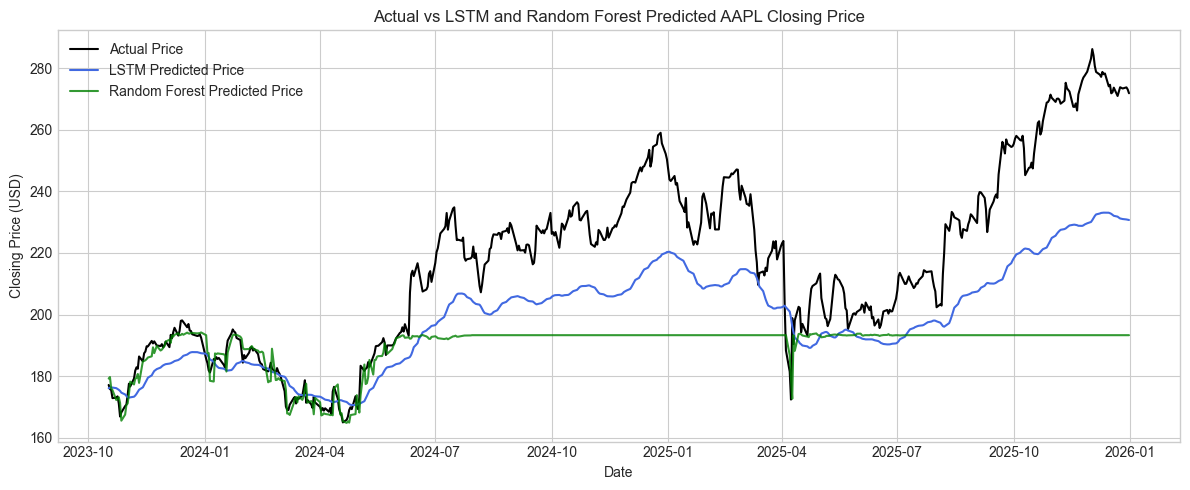

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(test_dates, actual_prices, label="Actual Price", color="black")
plt.plot(test_dates, lstm_pred, label="LSTM Predicted Price", color="royalblue")
plt.title("Actual vs LSTM Predicted AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_05_lstm_actual_vs_predicted.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(test_dates, actual_prices, label="Actual Price", color="black")
plt.plot(test_dates, rf_pred, label="Random Forest Predicted Price", color="green")
plt.title("Actual vs Random Forest Predicted AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_06_random_forest_actual_vs_predicted.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(test_dates, actual_prices, label="Actual Price", color="black")
plt.plot(test_dates, lstm_pred, label="LSTM Predicted Price", color="royalblue")
plt.plot(test_dates, rf_pred, label="Random Forest Predicted Price", color="green", alpha=0.8)
plt.title("Actual vs LSTM and Random Forest Predicted AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_07_combined_predictions.png", dpi=150)
plt.show()

## 12. Sample Prediction Table

In [22]:
results_df = pd.DataFrame({
    "Date": test_dates,
    "Actual Price": actual_prices,
    "LSTM Predicted Price": lstm_pred,
    "Random Forest Predicted Price": rf_pred,
})

results_df["LSTM Absolute Error"] = (
    results_df["Actual Price"] - results_df["LSTM Predicted Price"]
).abs()
results_df["Random Forest Absolute Error"] = (
    results_df["Actual Price"] - results_df["Random Forest Predicted Price"]
).abs()
results_df["LSTM Percentage Error (%)"] = (
    results_df["LSTM Absolute Error"] / (results_df["Actual Price"].abs() + 1e-8)
) * 100
results_df["Random Forest Percentage Error (%)"] = (
    results_df["Random Forest Absolute Error"] / (results_df["Actual Price"].abs() + 1e-8)
) * 100

display(results_df.head(10))

        Date  ...  Random Forest Percentage Error (%)
0 2023-10-17  ...                            1.175111
1 2023-10-18  ...                            2.205246
2 2023-10-19  ...                            0.323717
3 2023-10-20  ...                            1.501617
4 2023-10-23  ...                            0.414798
5 2023-10-24  ...                            0.452953
6 2023-10-25  ...                            1.201049
7 2023-10-26  ...                            2.656182
8 2023-10-27  ...                            1.581322
9 2023-10-30  ...                            1.618294

[10 rows x 8 columns]

## 13. Short Notes

- LSTM is suitable for sequential stock price data.
- Random Forest is used as a simpler comparison model.
- Stock prices are difficult to predict because of news, earnings, macroeconomic conditions, and investor sentiment.
- This notebook is for educational forecasting, not real trading.

## 14. Source Code Link

https://github.com/BingJun69/ML_Final_Assesment